In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Загружаем уже очищенные данные (1337 строк, без дубликата)
df = pd.read_csv('data/cleaned_data.csv')

# Быстрая проверка
print(f'Размер: {df.shape}') 
print(f"Пропуски: {df.isnull().sum().sum()}")  
print(f"Дубликаты: {df.duplicated().sum()}")  
df.head()

Размер: (1337, 7)
Пропуски: 0
Дубликаты: 0


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Визуальный анализ признаков

In [3]:
NUM_COLS = df.select_dtypes(include=['int64', 'float64']).columns
CAT_COLS = df.select_dtypes(include=['str']).columns

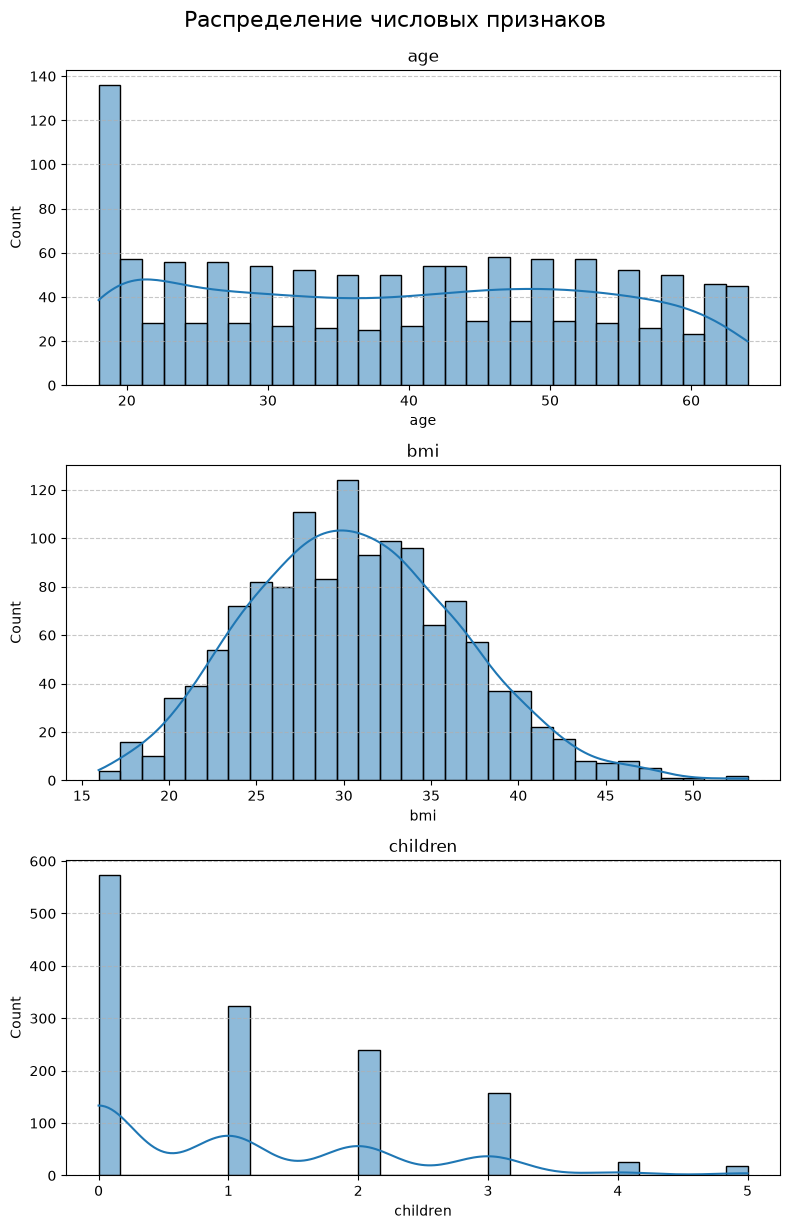

In [4]:
# Распределение числовых признаков 

num_cols_graph = NUM_COLS[NUM_COLS != 'charges']

fig, axes = plt.subplots(3, 1, figsize=(8, 12))
axes = axes.ravel()

for i, col in enumerate(num_cols_graph):
    sns.histplot(data=df, x=col, bins=30, kde=True, alpha=0.5, ax=axes[i])
    axes[i].set_title(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Распределение числовых признаков', y=1.02, fontsize=16)

plt.savefig('img/int_features.png', format='png', dpi=200, bbox_inches='tight')

plt.show()


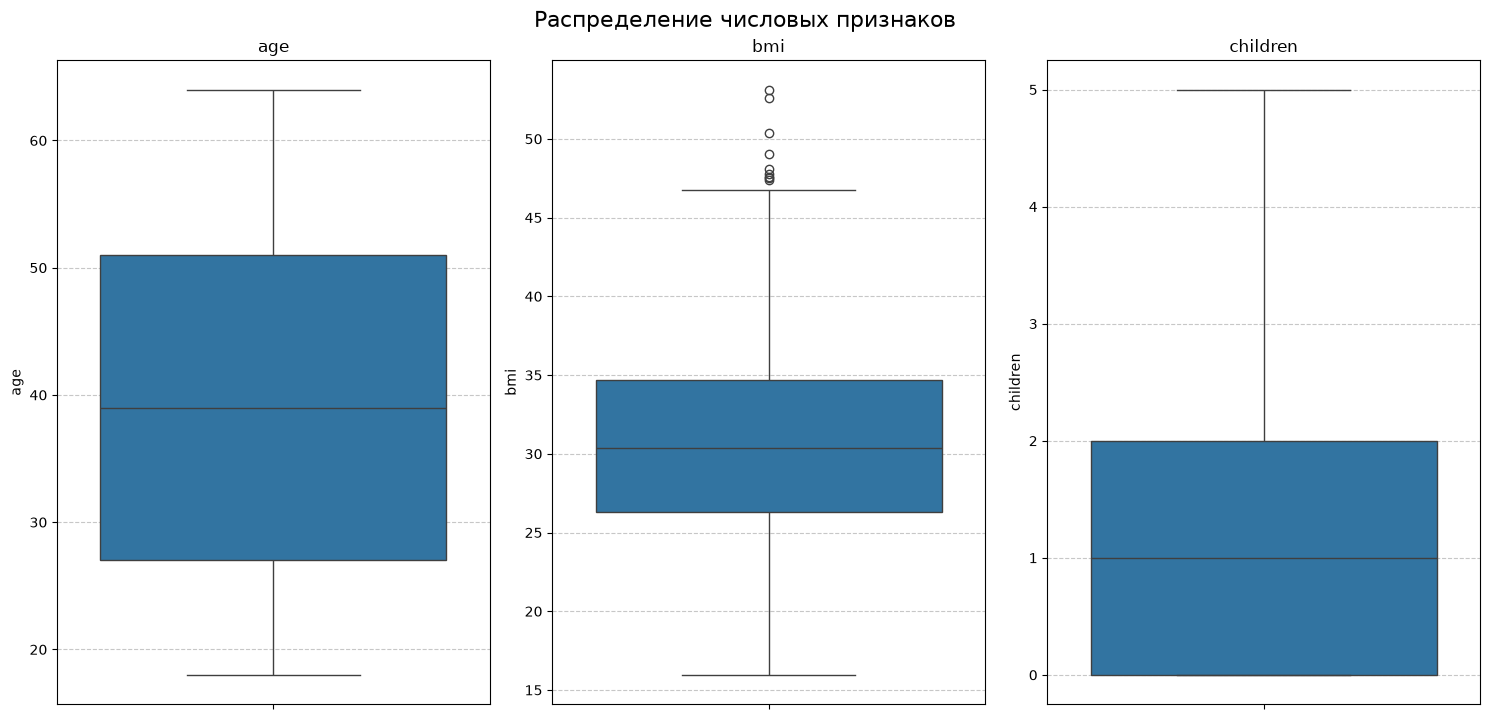

In [5]:
# Распределение числовых признаков 

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
axes = axes.ravel()

for i, col in enumerate(num_cols_graph):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Распределение числовых признаков', y=1.02, fontsize=16)

plt.savefig('img/int_features_box.png', format='png', dpi=200, bbox_inches='tight')

plt.show()


### Числовые признаки: что видим

По гистограммам и boxplot видим:
- Возраст распределен равномерно от 18 до 64 лет, пропусков и перекосов нет
- Индекс массы тела сконцентрирован вокруг 30 со средним 30.6, хвосты до 53 единичны и не требуют удаления
- Число детей — порядковая переменная: у большинства 0-1 ребенок, 5 детей встречаются крайне редко


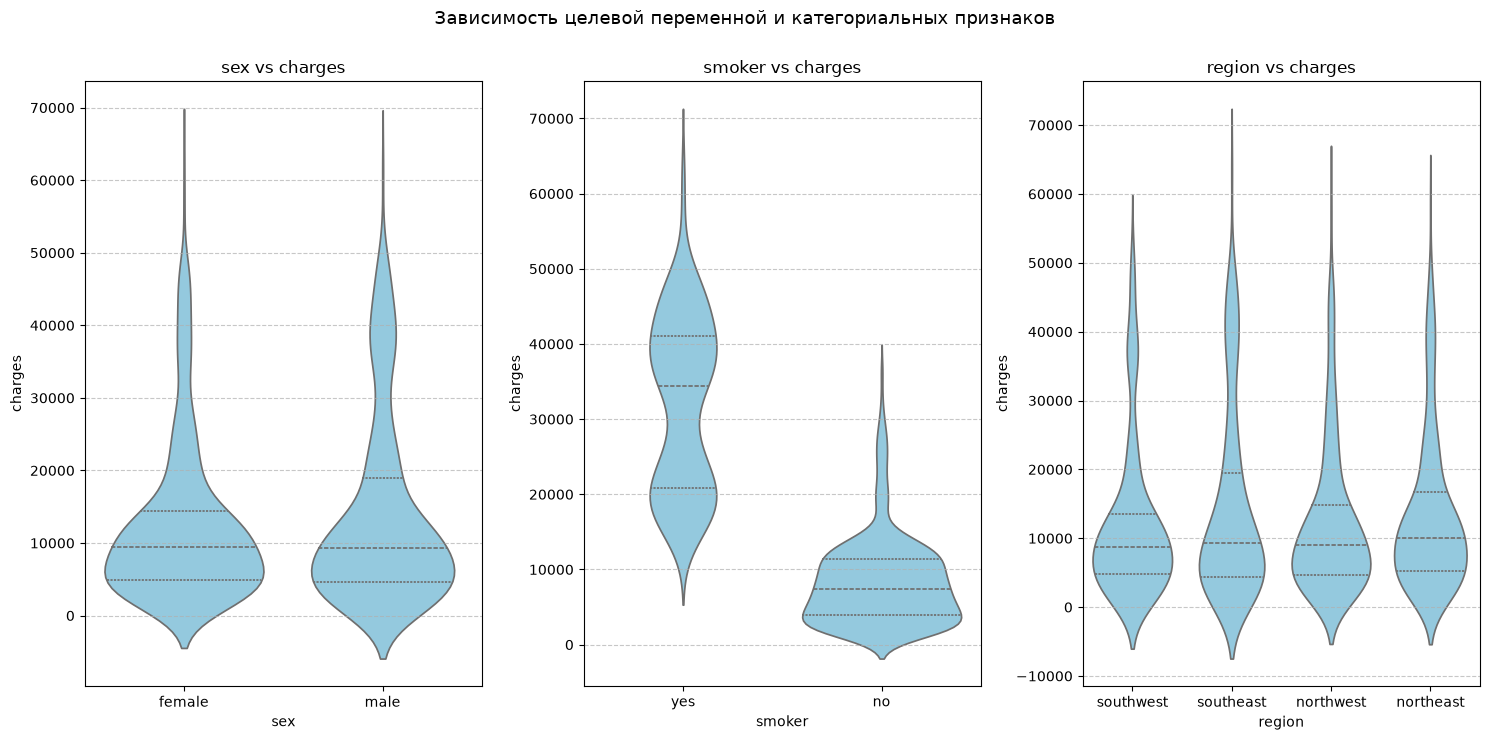

In [6]:
# Зависимость целевой переменной и категориальных признаков

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
axes = axes.ravel()


for i, col in enumerate(CAT_COLS):
    sns.violinplot(data=df, x=df[col], y=df['charges'], ax=axes[i], inner="quartile", color="skyblue" )
    axes[i].set_title(f'{col} vs charges')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Зависимость целевой переменной и категориальных признаков', y=1.05, fontsize=13)

plt.savefig('img/cat_features_violin.png', format='png', dpi=200, bbox_inches='tight')

plt.show()

### Рассмотрим каждый признак отдельно

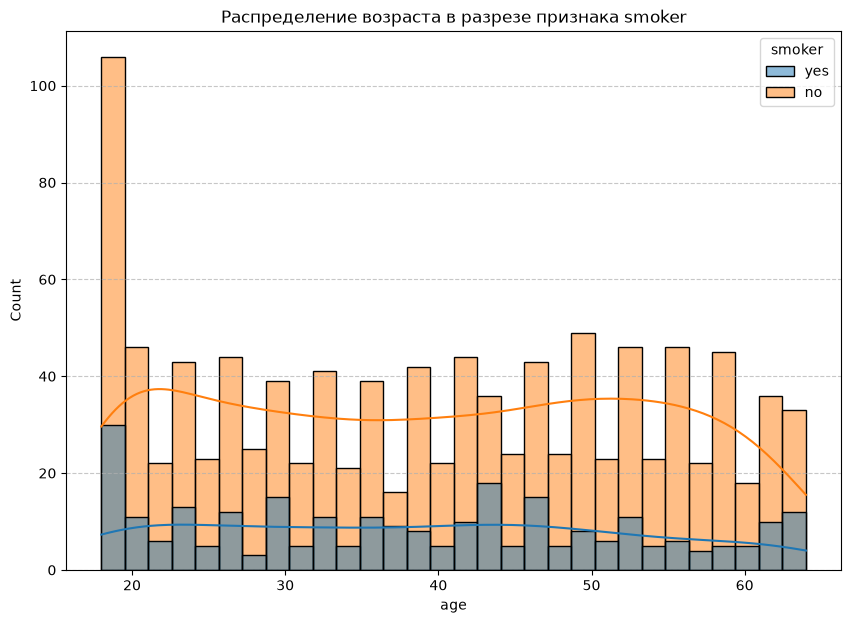

In [7]:
# Распределение age в разрезе признака smoker
plt.figure(figsize=(10, 7))
sns.histplot(data=df, x='age', hue='smoker', bins=30, kde=True, alpha=0.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Распределение возраста в разрезе признака smoker')
plt.show()

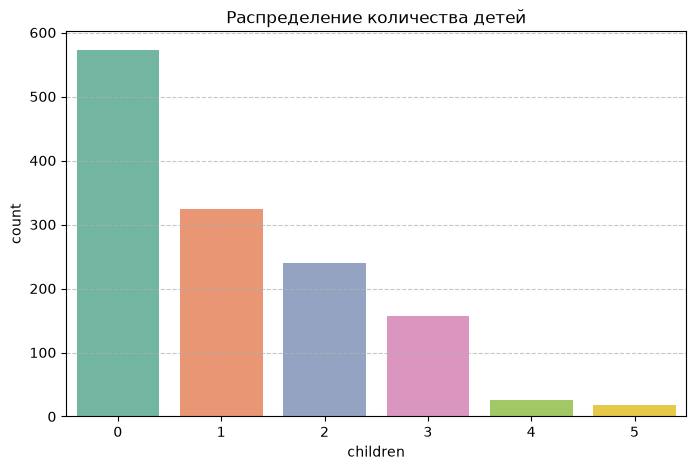

Процент от общего количества
children
0    42.857
1    24.233
2    17.951
3    11.743
4     1.870
5     1.346
Name: proportion, dtype: float64


In [8]:
# Распределение количества детей и доли от общего количества

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='children', palette='Set2', hue='children', legend=False)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Распределение количества детей')
plt.show()

print(f'Процент от общего количества\n{(df['children'].value_counts(normalize=True) * 100).round(3)}')

### Категориальные признаки: баланс и связь с ценой


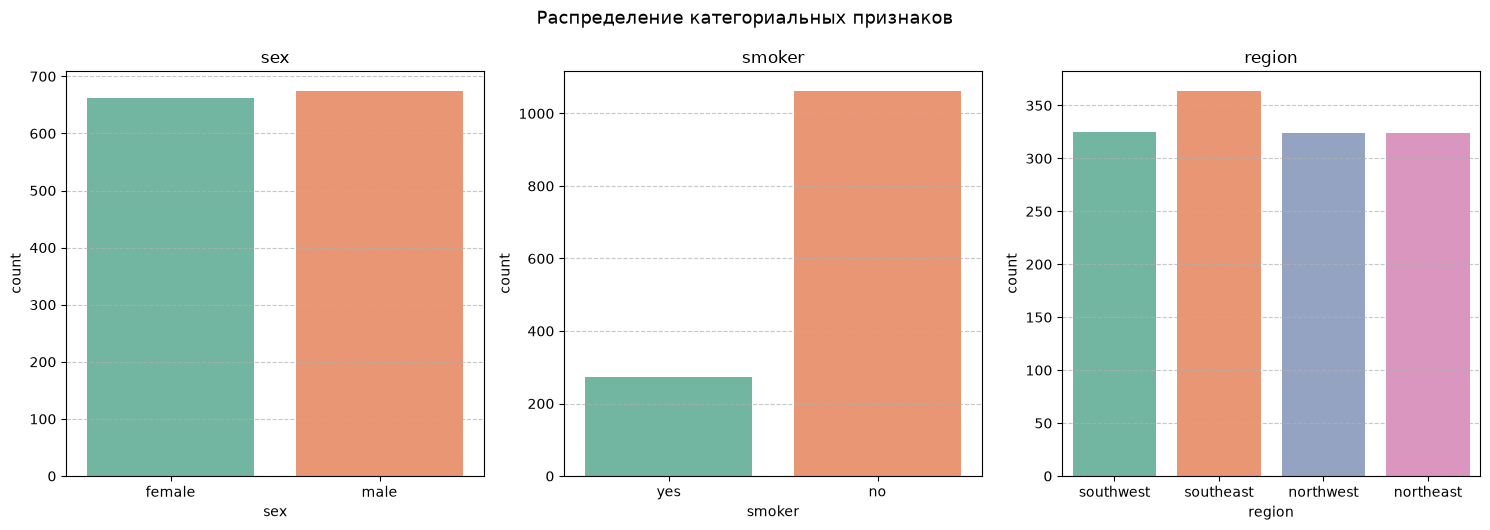

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.ravel()


for i, col in enumerate(CAT_COLS):
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2', hue=col, legend=False)
    axes[i].set_title(f'{col}')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Распределение категориальных признаков', y=1.05, fontsize=13)

plt.savefig('img/cat_features_count.png', format='png', dpi=200, bbox_inches='tight')

plt.show()

### Таблицы и графики раздельно

Ниже сначала идут таблицы `count/mean/median` по каждой категории — это точные цифры, затем boxplot по распределению и barplot по медиане. Смотрим их парой: таблица дает значение, график — разброс


sex,female,male
count,662.000000,675.000000
mean,12569.578844,13974.998864
median,9412.962500,9377.904700
std,11128.703801,12971.958663
min,1607.510100,1121.873900
max,63770.428010,62592.873090


smoker,no,yes
count,1063.000000,274.000000
mean,8440.660307,32050.231832
median,7345.726600,34456.348450
std,5992.973800,11541.547176
min,1121.873900,12829.455100
max,36910.608030,63770.428010


region,northeast,northwest,southeast,southwest
count,324.000000,324.000000,364.000000,325.000000
mean,13406.384516,12450.840844,14735.411438,12346.937377
median,10057.652025,8976.977250,9294.131950,8798.593000
std,11255.803066,11073.125699,13971.098589,11557.179101
min,1694.796400,1621.340200,1121.873900,1241.565000
max,58571.074480,60021.398970,63770.428010,52590.829390


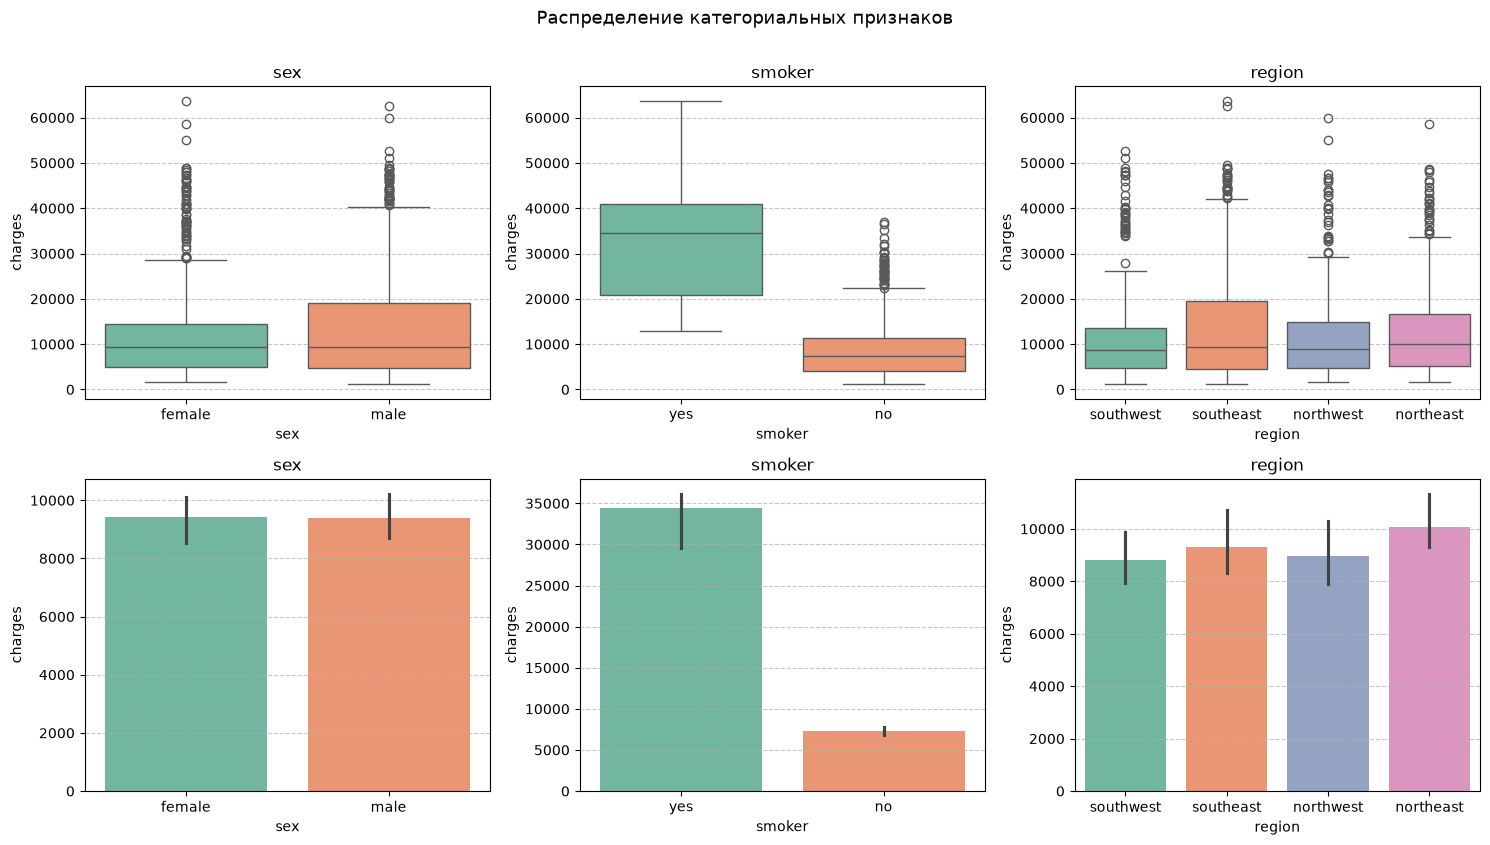

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()


for i, col in enumerate(CAT_COLS):
    group_df = df.groupby(col)['charges'].agg(['count','mean','median','std','min','max'])
    sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette='Set2', hue=col, legend=False)
    axes[i].set_title(f'{col}')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    display(group_df.T)

for i, col in enumerate(CAT_COLS):
    sns.barplot(data=df, x=col, y='charges', estimator='median', ax=axes[i+3], palette='Set2', hue=col, legend=False)

    axes[i+3].set_title(f'{col}')
    axes[i+3].grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.suptitle('Распределение категориальных признаков', y=1.05, fontsize=13)

plt.savefig('img/cat_features_box_bar.png', format='png', dpi=200, bbox_inches='tight')

plt.show()


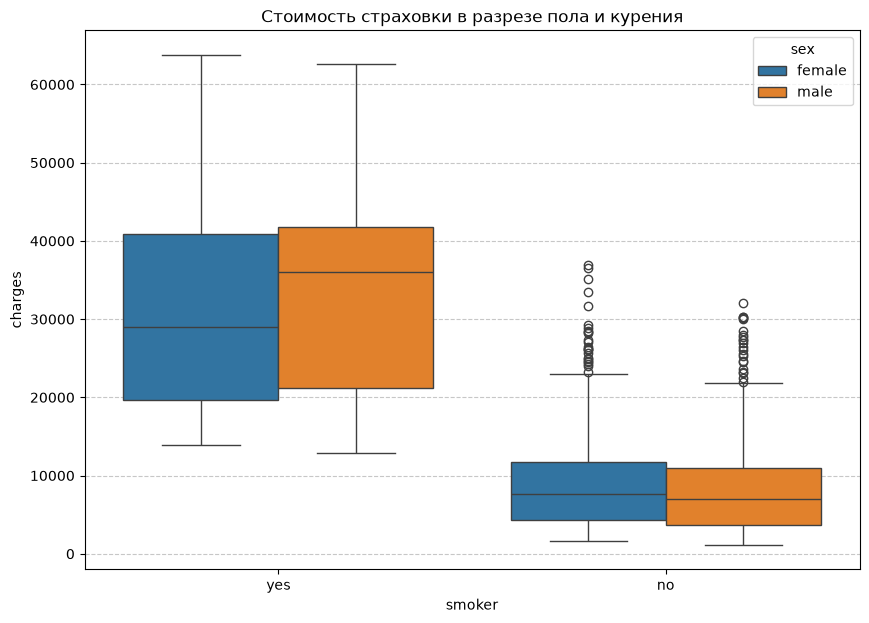

smoker  sex   
no      female     7639.417450
        male       6986.101975
yes     female    28950.469200
        male      36085.219000
Name: charges, dtype: float64


In [11]:
# В разрезе пола и курения
plt.figure(figsize=(10, 7))
sns.boxplot(data=df, x='smoker', y='charges', hue='sex')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Стоимость страховки в разрезе пола и курения')
plt.show()

print(df.groupby(['smoker','sex'])['charges'].median())

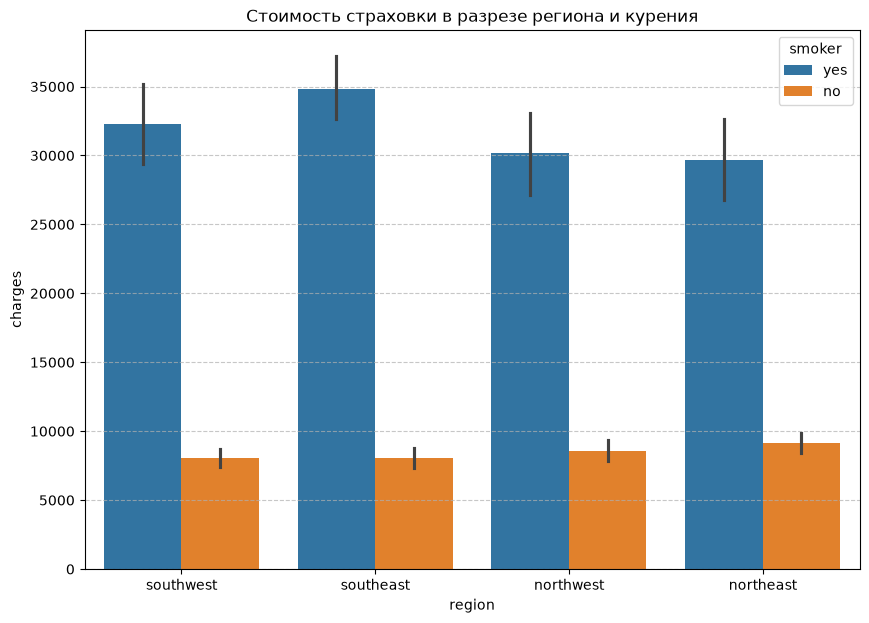

region    northeast     northwest   southeast   southwest
smoker                                                   
no       8342.90875   7259.232050   6652.5288   7348.1420
yes     28101.33305  27488.996475  37484.4493  35165.2565


In [12]:
# В разрезе региона и курения
plt.figure(figsize=(10, 7))
sns.barplot(data=df, x='region', y='charges', hue='smoker')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Стоимость страховки в разрезе региона и курения')
plt.show()

print(df.groupby(['smoker','region'])['charges'].median().unstack())


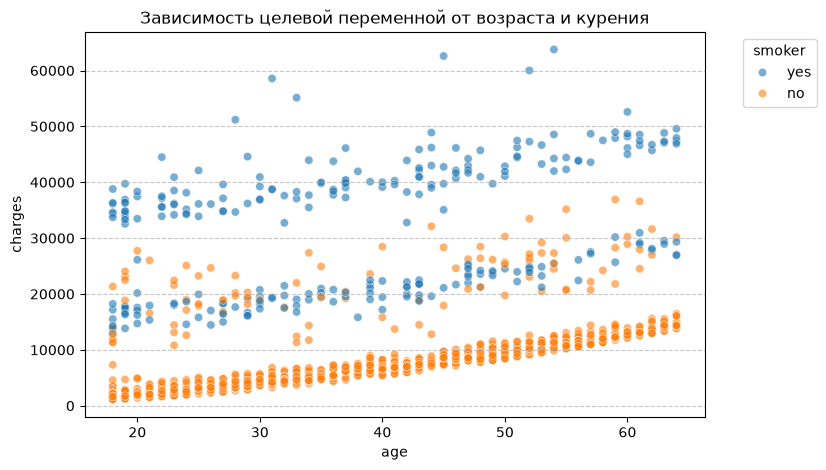

In [13]:
# Зависимость целевой переменной от возраста и курения
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.6)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), title='smoker')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Зависимость целевой переменной от возраста и курения')
plt.show()

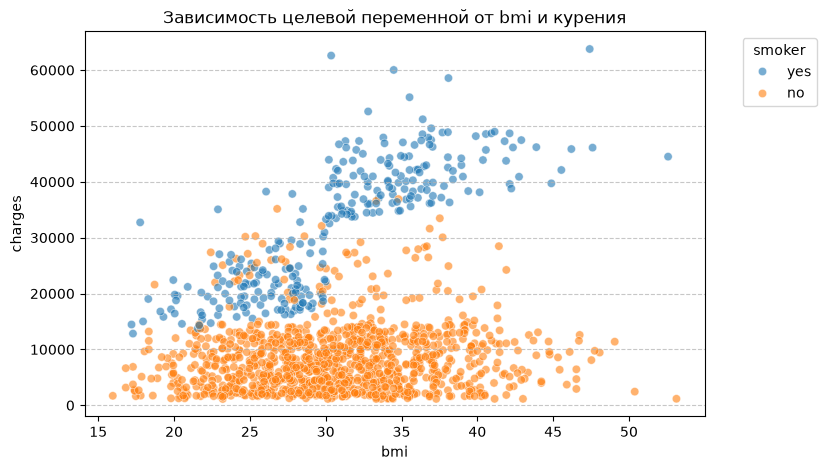

In [14]:
# Зависимость целевой переменной от bmi и курения
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), title='smoker')
plt.title('Зависимость целевой переменной от bmi и курения')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Что видно по взаимодействиям

Если смотреть просто возраст против цены, точки ползут вверх, но когда добавляем разрез по `smoker`, видно другое: нижнее облако точек некурящих растет плавно, а верхнее облако точек курильщиков уходит круто вверх с возрастом. 

По полу внутри этих облаков разница тоже есть — мужчины-курильщики в медиане дороже женщин (36085 против 28950).

С `bmi` еще нагляднее: до 30 точки перемешаны, а после 30 курильщики резко отрываются вверх. 

По регионам картина та же — везде курильщики в 3-4 раза выше, юго-восток просто чуть дороже остальных

In [15]:
# Вычислим корреляцию 
corr_pearson = df.corr(method='pearson', numeric_only=True)
corr_spearman = df.corr(method='spearman', numeric_only=True)


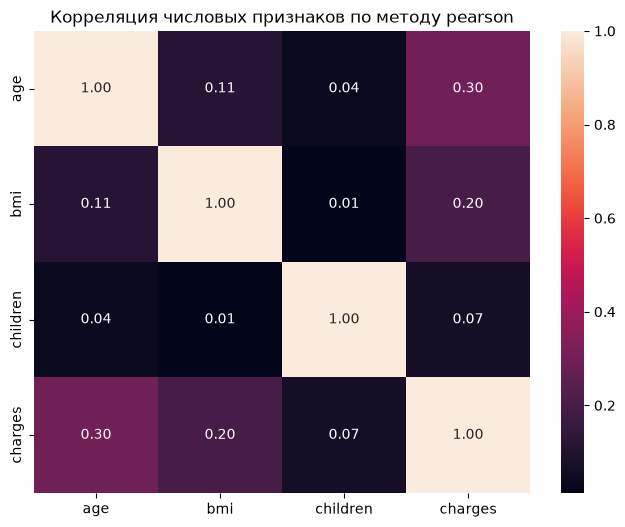

In [16]:
# Корреляция по Пирсону
plt.figure(figsize=(8, 6))
sns.heatmap(corr_pearson, annot=True, fmt='.2f')
plt.title('Корреляция числовых признаков по методу pearson')

plt.savefig('img/corr_pearson.png', format='png', dpi=200, bbox_inches='tight')

plt.show()

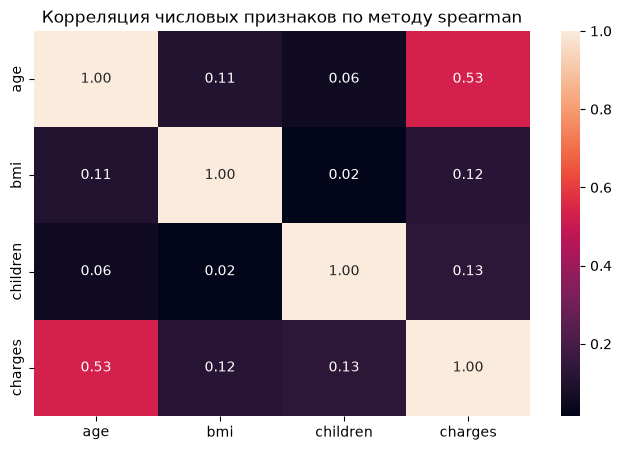

In [17]:
# Корреляция по Спирмену
plt.figure(figsize=(8, 5))
sns.heatmap(corr_spearman, annot=True, fmt='.2f')
plt.title('Корреляция числовых признаков по методу spearman')

plt.savefig('img/corr_spearman.png', format='png', dpi=200, bbox_inches='tight')

plt.show()

### Что говорят корреляции

Посчитали оба варианта — Пирсона и Спирмена, чтобы не пропустить нелинейность. По сути они сошлись: `age` держит около 0.30, `bmi` около 0.20, а `children` болтается возле нуля

Исходя из этого - мультиколлинеарности между признаками нет


In [18]:
# Рассмотрим стоимость страховки в разрезе возрастных групп
age_group = pd.cut(df['age'], bins=[18,30,45,60,65], right=False)
stats_age = df.groupby(age_group, observed=True)['charges'].agg(['size', 'median'])  
age_group_counts = stats_age['size']
median_charges = stats_age['median'] 

print(f'Распределение наблюдений по группам {age_group_counts}\n')
print(f'Медианная стоимость по группам {median_charges}')

Распределение наблюдений по группам age
[18, 30)    416
[30, 45)    392
[45, 60)    415
[60, 65)    114
Name: size, dtype: int64

Медианная стоимость по группам age
[18, 30)     3220.371575
[30, 45)     6798.160625
[45, 60)    11187.656700
[60, 65)    14255.400500
Name: median, dtype: float64


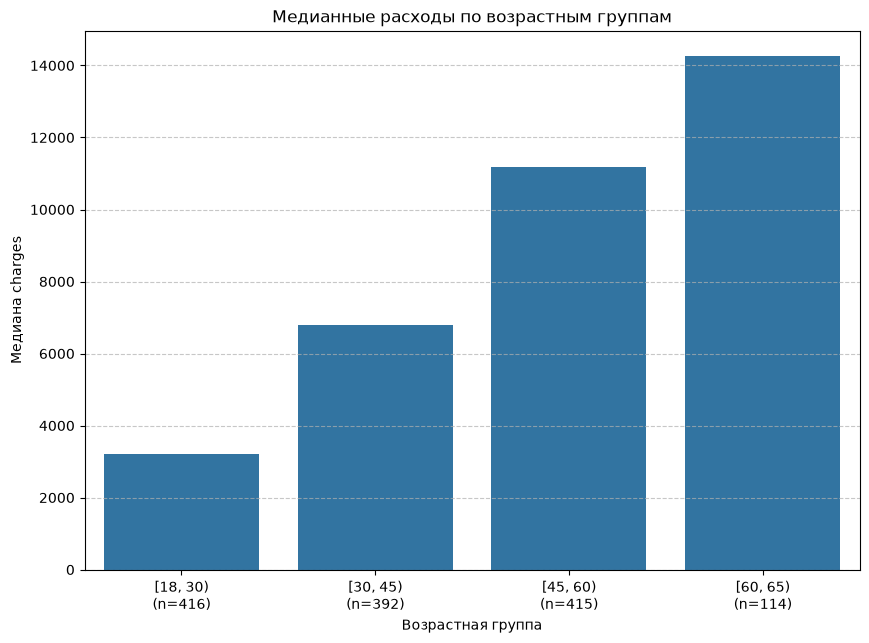

In [19]:
# Визуализируем полученные данные по возрастным группам
labels = [f"{interval}\n(n={count})" 
          for interval, count in zip(stats_age.index, stats_age['size'].values)]

plt.figure(figsize=(10,7))
sns.barplot(x=stats_age.index, y=stats_age['median'].values)
plt.xticks(range(len(labels)), labels)

plt.ylabel('Медиана charges')
plt.xlabel('Возрастная группа')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Медианные расходы по возрастным группам')

plt.savefig('img/median_age_group.png', format='png', dpi=200, bbox_inches='tight')


plt.show()

In [20]:
# Рассмотрим стоимость страховки в разрезе категорий bmi по ВОЗ
bmi_bins = [0, 18.5, 25, 30, 35, 40, 100]
bmi_labels = ['deficit', 'normal', 'overweight','obesity1', 'obesity2', 'obesity3']

bmi_group = pd.cut(df['bmi'], bins=bmi_bins, labels=bmi_labels, right=False)
stats_bmi = df.groupby(bmi_group, observed=True)['charges'].agg(['size', 'median']) 
bmi_group_counts = stats_bmi['size']
median_charges_bmi = stats_bmi['median']  

print(f'Распределение наблюдений по группам {bmi_group_counts}\n')
print(f'Медианная стоимость по группам {median_charges_bmi}')

Распределение наблюдений по группам bmi
deficit        20
normal        225
overweight    386
obesity1      390
obesity2      225
obesity3       91
Name: size, dtype: int64

Медианная стоимость по группам bmi
deficit        6759.262475
normal         8603.823400
overweight     8659.378000
obesity1       9573.461150
obesity2      11264.541000
obesity3       9748.910600
Name: median, dtype: float64


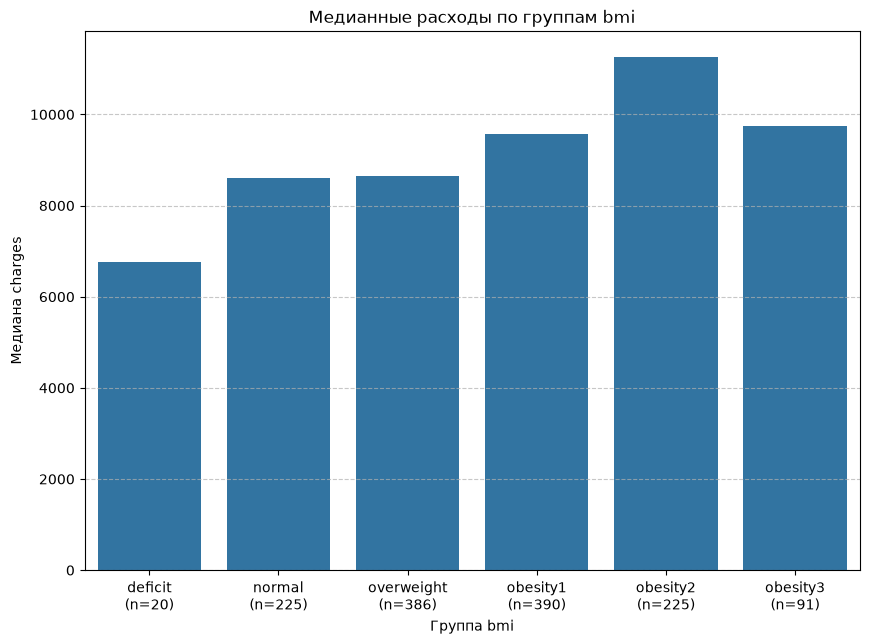

In [21]:
# Визуализируем полученные данные по группам bmi
labels = [f"{interval}\n(n={count})" 
          for interval, count in zip(stats_bmi.index, stats_bmi['size'].values)]

plt.figure(figsize=(10,7))
sns.barplot(x=stats_bmi.index, y=stats_bmi['median'].values)
plt.xticks(range(len(labels)), labels)

plt.ylabel('Медиана charges')
plt.xlabel('Группа bmi')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Медианные расходы по группам bmi')

plt.savefig('img/median_bmi_group.png', format='png', dpi=200, bbox_inches='tight')

plt.show()

## Итог после визуального анализа

1. Признак курения сильно драйвит целевую переменную. Медианная стоимость для некурящих составляет 7345 долларов против 34456 для курящих, средние значения — 8440 против 32050. Минимальный счет курильщика начинается с 12829 долларов, то есть сегменты практически не пересекаются.

2. Возраст и масса тела работают, но только в связке с курением. Медиана растет по возрастным группам последовательно: 3220 в 18-30 лет, 6798 в 30-45, 11187 в 45-60 и 14255 после 60. По индексу массы тела линейная корреляция умеренная — около 0.20 по Пирсону против 0.30 у возраста, однако после порога 30 в сочетании с курением мы видим резкий отрыв стоимости вверх. Внутри сегмента курильщиков дополнительно выделяется пол: мужчины дороже женщин по медиане — 36085 против 28950.

3. Что не влияет. Пол в целом нейтрален: медианы 9412 и 9377 практически равны. Регион также не дает оснований для дифференциации тарифа: медианы лежат в узком коридоре 8798-10057. Число детей слабо связано с ценой, корреляция около 0.07, у 42.8% клиентов детей нет.

Вывод для дальнейшей работы:

Линейных связей недостаточно, поэтому в следующий этап мы выносим построение новых признаков